In [26]:
import pandas as pd

In [27]:
txt_file_path = 'data/Ads.txt'
# Sử dụng index_col='Id' để đặt cột Id làm index
df_txt = pd.read_csv(txt_file_path, sep=r'\s+', index_col='Id')
display(df_txt.head())

,youtube,facebook,newspaper,sales
Id,,,,
1,276.12,45.36,83.04,26.52
2,53.40,47.16,54.12,12.48
3,20.64,55.08,83.16,11.16
4,181.80,49.56,70.20,22.20
5,216.96,12.96,70.08,15.48


In [28]:
df_txt.info()

<class 'pandas.DataFrame'>
Index: 199 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   youtube    199 non-null    float64
 1   facebook   199 non-null    float64
 2   newspaper  199 non-null    float64
 3   sales      199 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


In [29]:
# Hiển thị thống kê mô tả cho tất cả các cột số
description = df_txt.describe()
display(description)

,youtube,facebook,newspaper,sales
count,199.000000,199.000000,199.000000,199.000000
mean,176.749749,28.011256,36.805628,16.853065
std,103.198035,17.810830,26.124069,6.265850
min,0.840000,0.000000,0.360000,1.920000
25%,88.860000,12.060000,15.420000,12.480000
50%,179.760000,27.960000,31.080000,15.480000
75%,262.980000,43.860000,54.120000,20.880000
max,355.680000,59.520000,136.800000,32.400000


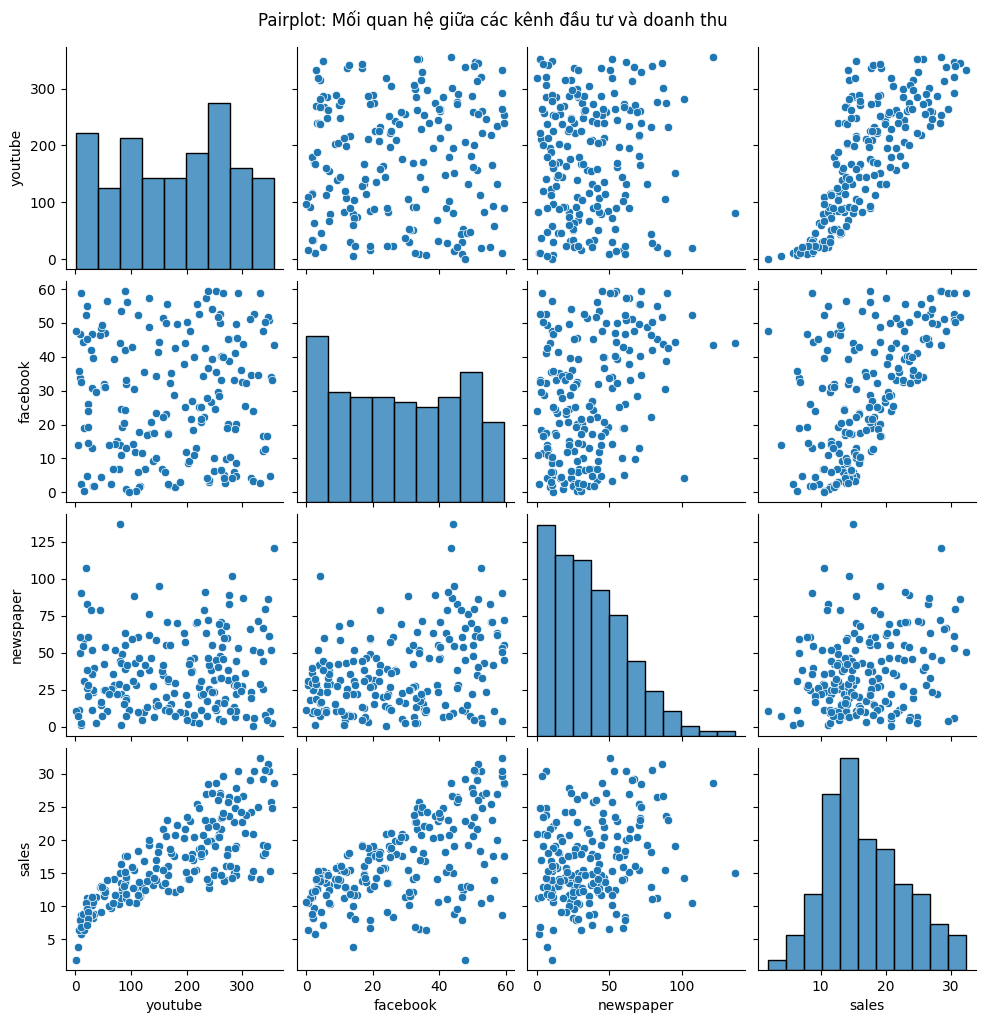

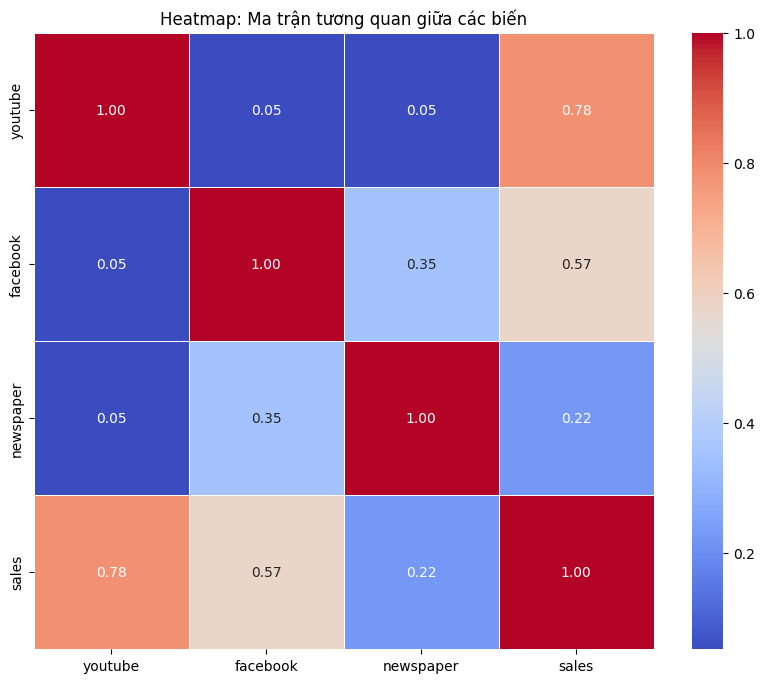

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Vẽ Pairplot
sns.pairplot(df_txt)
plt.suptitle('Pairplot: Mối quan hệ giữa các kênh đầu tư và doanh thu', y=1.02)
plt.show()

# 2. Tính ma trận tương quan
corr_matrix = df_txt.corr()

# 3. Vẽ Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap: Ma trận tương quan giữa các biến')
plt.show()


In [31]:

import numpy as np

# Phân hoạch doanh thu theo các ngưỡng cụ thể: 0-10, 10-20, >20
bins = [0, 10, 20, np.inf]
labels = ['Low', 'Medium', 'High']
df_txt['sales_level'] = pd.cut(df_txt['sales'], bins=bins, labels=labels)

# Thống kê số lượng mẫu theo từng mức
print("Số lượng mẫu tin theo doanh thu ứng với 3 mức phân hoạch mới:")
display(df_txt['sales_level'].value_counts())

Số lượng mẫu tin theo doanh thu ứng với 3 mức phân hoạch mới:


sales_level
Medium    118
High       59
Low        22
Name: count, dtype: int64

Kết quả kiểm thử mô hình:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00         7
         Low       1.00      0.50      0.67         4
      Medium       0.94      1.00      0.97        29

    accuracy                           0.95        40
   macro avg       0.98      0.83      0.88        40
weighted avg       0.95      0.95      0.94        40



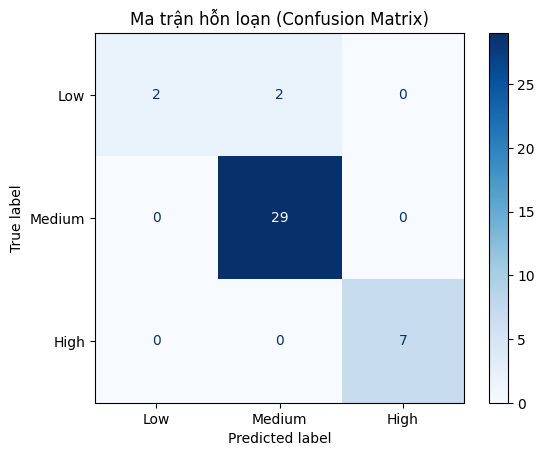

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Chuẩn bị dữ liệu
X = df_txt[['youtube', 'facebook', 'newspaper']]
y = df_txt['sales_level']

# Chia 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Huấn luyện mô hình
clf = DecisionTreeClassifier(random_state=42,  min_samples_leaf=5) # dùng gini
clf.fit(X_train, y_train)

# Dự đoán
y_pred = clf.predict(X_test)

# Kết quả kiểm thử
print("Kết quả kiểm thử mô hình:")
print(classification_report(y_test, y_pred))

# Ma trận hỗn loạn
cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues')
plt.title('Ma trận hỗn loạn (Confusion Matrix)')
plt.show()

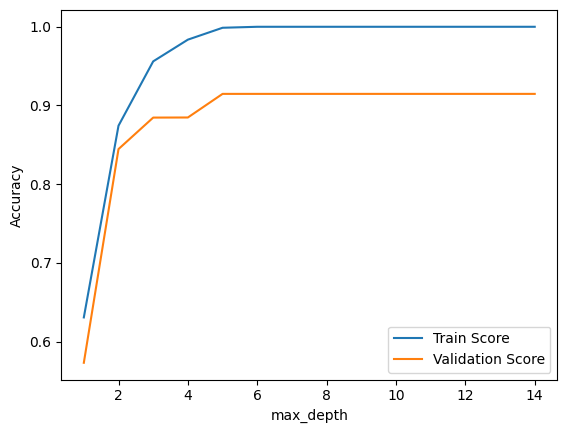

In [33]:
import numpy as np
from sklearn.model_selection import validation_curve
param_range = np.arange(1, 15)
train_scores, test_scores = validation_curve(
DecisionTreeClassifier(criterion='entropy', random_state=42),
X, y, param_name="max_depth", param_range=param_range, cv=5, scoring="accuracy")
plt.plot(param_range, np.mean(train_scores, axis=1), label="Train Score")
plt.plot(param_range, np.mean(test_scores, axis=1), label="Validation Score")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [34]:
# Thực hiện K-fold Cross Validation (k=5)
scores = cross_val_score(clf, X, y, cv=5)
print(f"Độ chính xác trung bình qua 5-fold cross-validation: {scores.mean():.2f} (+/- {scores.std() * 2:.2f})")

Độ chính xác trung bình qua 5-fold cross-validation: 0.92 (+/- 0.05)


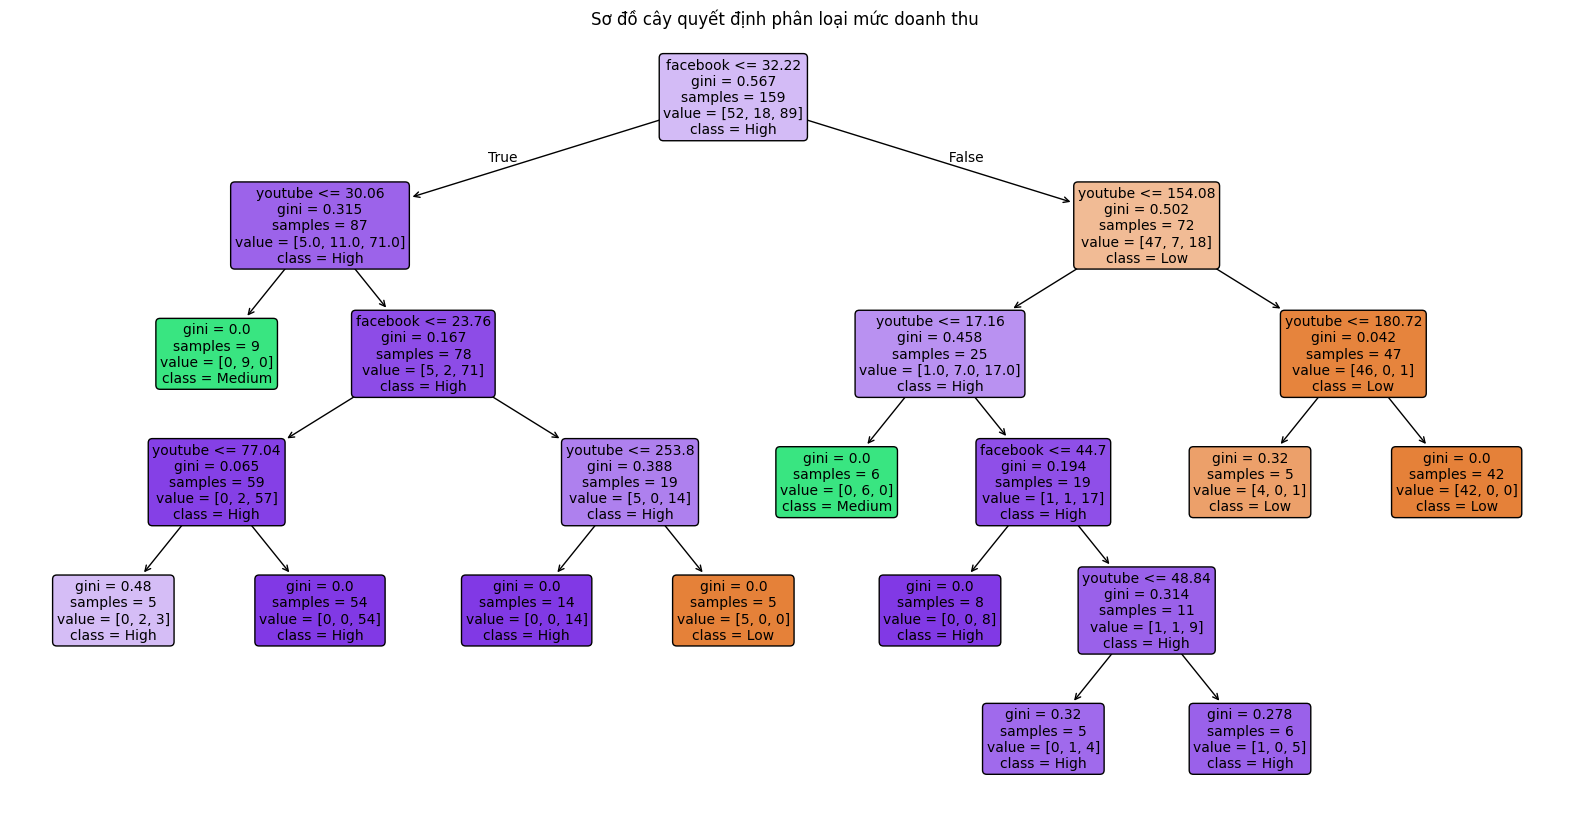

In [35]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(clf,
          feature_names=['youtube', 'facebook', 'newspaper'],
          class_names=['Low', 'Medium', 'High'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Sơ đồ cây quyết định phân loại mức doanh thu")
plt.show()

In [36]:
# Dữ liệu mới cần dự báo
new_data = pd.DataFrame({
    'youtube': [118, 34],
    'facebook': [63, 43],
    'newspaper': [19, 14]
})

# Thực hiện dự báo
predictions = clf.predict(new_data)

# Hiển thị kết quả
for i, pred in enumerate(predictions):
    print(f"Kịch bản {i+1}:")
    print(f"- Chi phí: YouTube={new_data.iloc[i]['youtube']}, Facebook={new_data.iloc[i]['facebook']}, Newspaper={new_data.iloc[i]['newspaper']}")
    print(f"=> Dự báo mức doanh thu: {pred}\n")

Kịch bản 1:
- Chi phí: YouTube=118, Facebook=63, Newspaper=19
=> Dự báo mức doanh thu: Medium

Kịch bản 2:
- Chi phí: YouTube=34, Facebook=43, Newspaper=14
=> Dự báo mức doanh thu: Medium



In [37]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential([
    keras.Input(shape=(3,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')